# Material Penetration Experiment Results

This notebook visualises the corrected hybrid workflow:

- 56 bare-detector Allpix simulations provide photon-equivalent detector response.
- Analytical Beer-Lambert attenuation gives alloy transmission.
- Passive-alloy Allpix transport cross-checks: a 3-energy (40/80/120 keV) spot check for Medipix3, HEXITEC-proxy, and Timepix3 against Alloy 2 brass, plus a full 14-energy curve for EIGER2.
- D4 is Timepix3 bonded to a 1 mm CdTe sensor, replacing the earlier custom thick CdTe detector.
- **EIGER2 correction**: EIGER2's hard 80 keV upper threshold makes the analytic Beer-Lambert x bare-response shortcut miss Compton-downscattered photons re-entering its high-efficiency window, by up to +344% at high energy (see the Transport Cross-Check section). EIGER2/alloy2 therefore uses the directly measured transport fraction, and EIGER2's other four alloys use an alloy2-calibrated correction factor -- not independently validated per alloy, see `build_eiger2_alloy2_correction()` in `material_penetration_experiment.py`.

Important correction: the final detected-count tables use event-level detection efficiency, not raw cluster multiplicity, so detected counts cannot exceed transmitted photons (except EIGER2's transport/corrected rows, which are allowed to by design -- see `detection_method` column).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'analysis' / 'material_penetration').exists():
        ROOT = candidate
        break

BASE = ROOT / 'analysis' / 'material_penetration'
SPECTRA = ROOT / 'spectra' / '150kvp_weights.csv'

spectrum = pd.read_csv(SPECTRA)
spectrum_summary = pd.read_csv(BASE / 'spectrum_summary.csv')
checks = pd.read_csv(BASE / 'validation_checks.csv')
response = pd.read_csv(BASE / 'detector_response.csv')
detector_bins = pd.read_csv(BASE / 'detector_energy_bin_response.csv')
attenuation = pd.read_csv(BASE / 'alloy_attenuation.csv')
per_energy = pd.read_csv(BASE / 'per_energy_results.csv')
bin_results = pd.read_csv(BASE / 'per_detector_energy_bin_results.csv')
combined = pd.read_csv(BASE / 'combined_results.csv')
transport = pd.read_csv(BASE / 'transport_validation.csv')
discrimination = pd.read_csv(BASE / 'alloy_discrimination_cnr.csv')

plt.style.use('seaborn-v0_8-whitegrid')

## Presentation Figures

These are the clean figures to use first. They show the source, attenuation, detector response, final matrix, performance ranking, energy-bin counts, and transport validation.

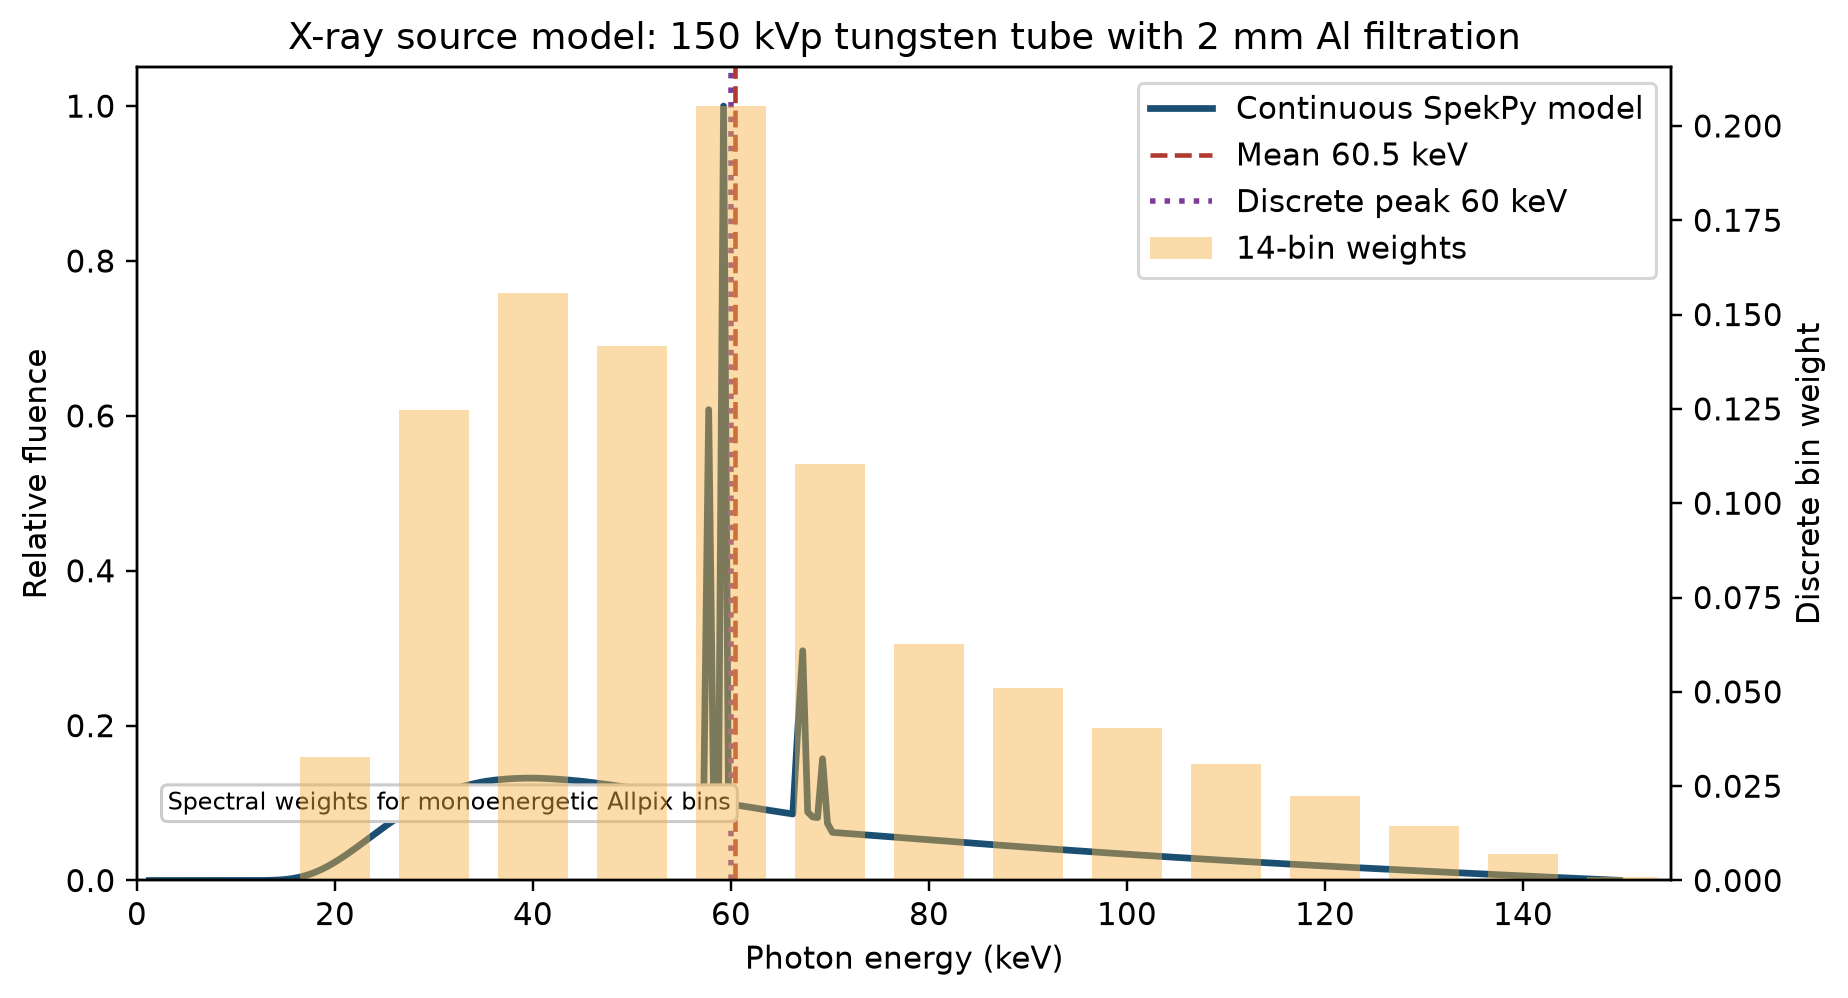

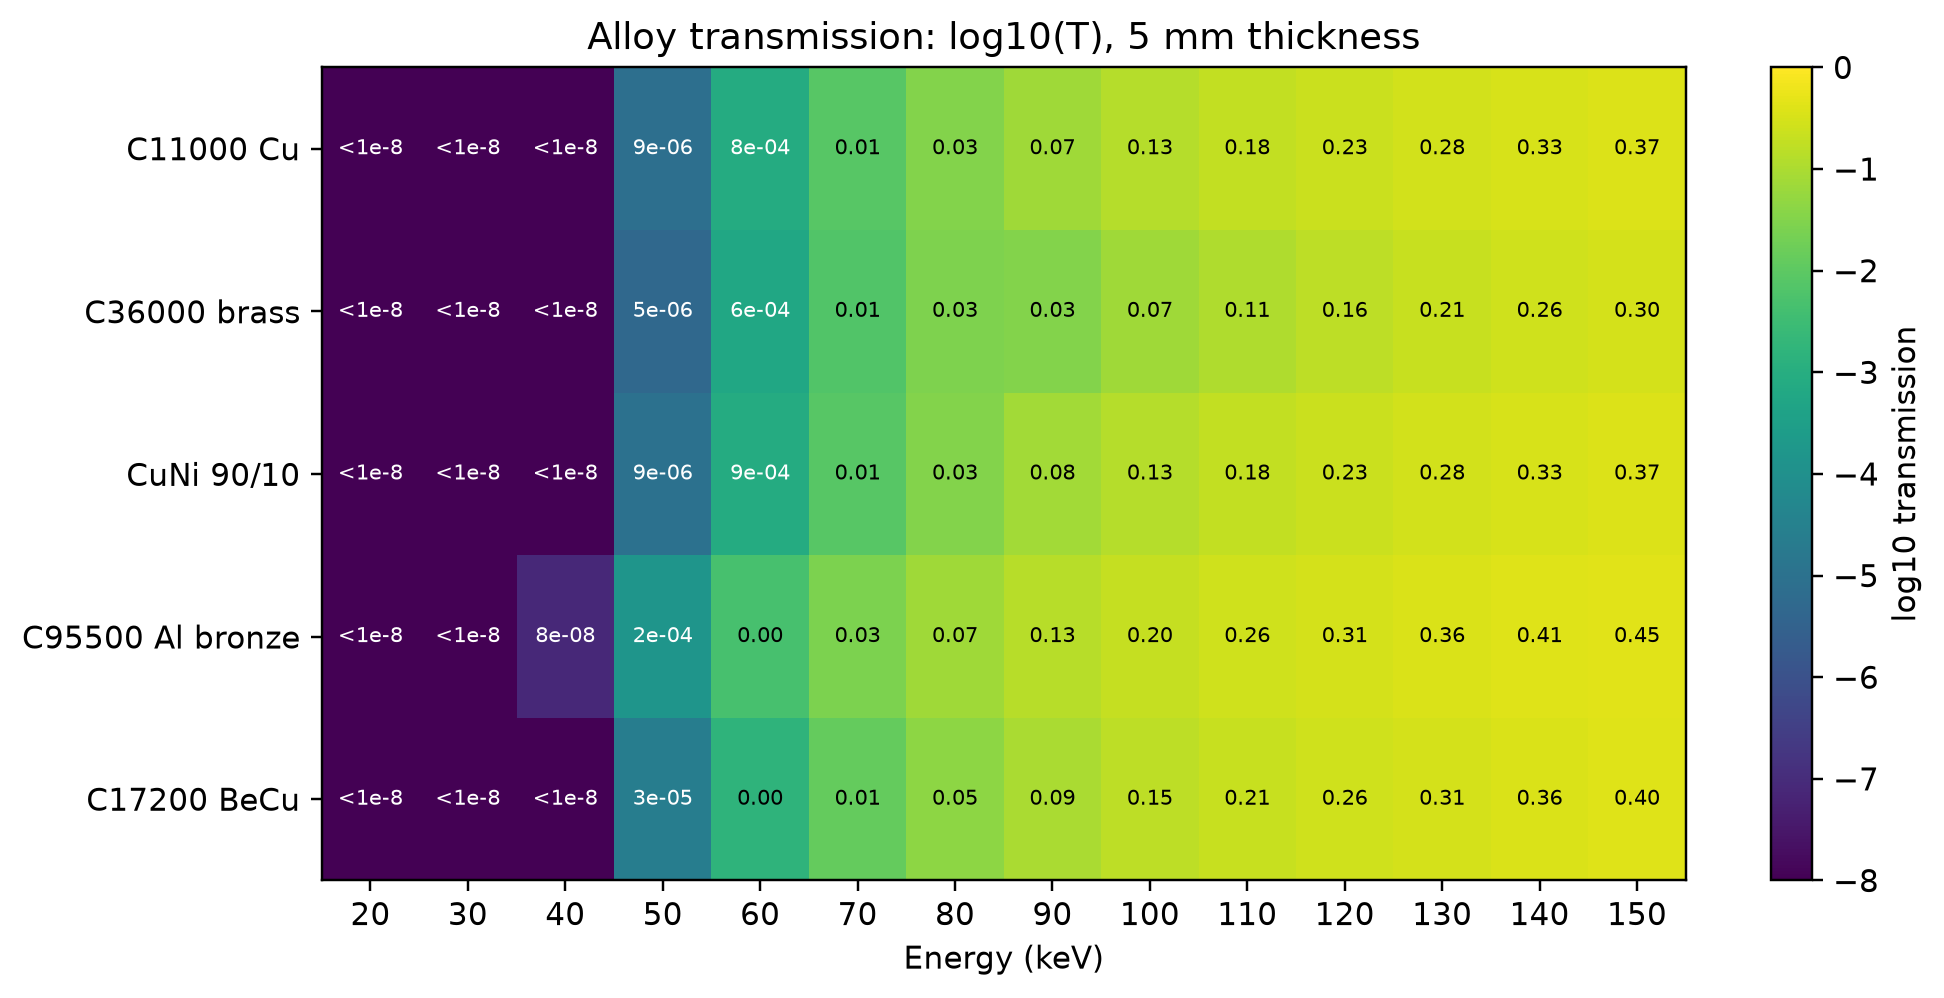

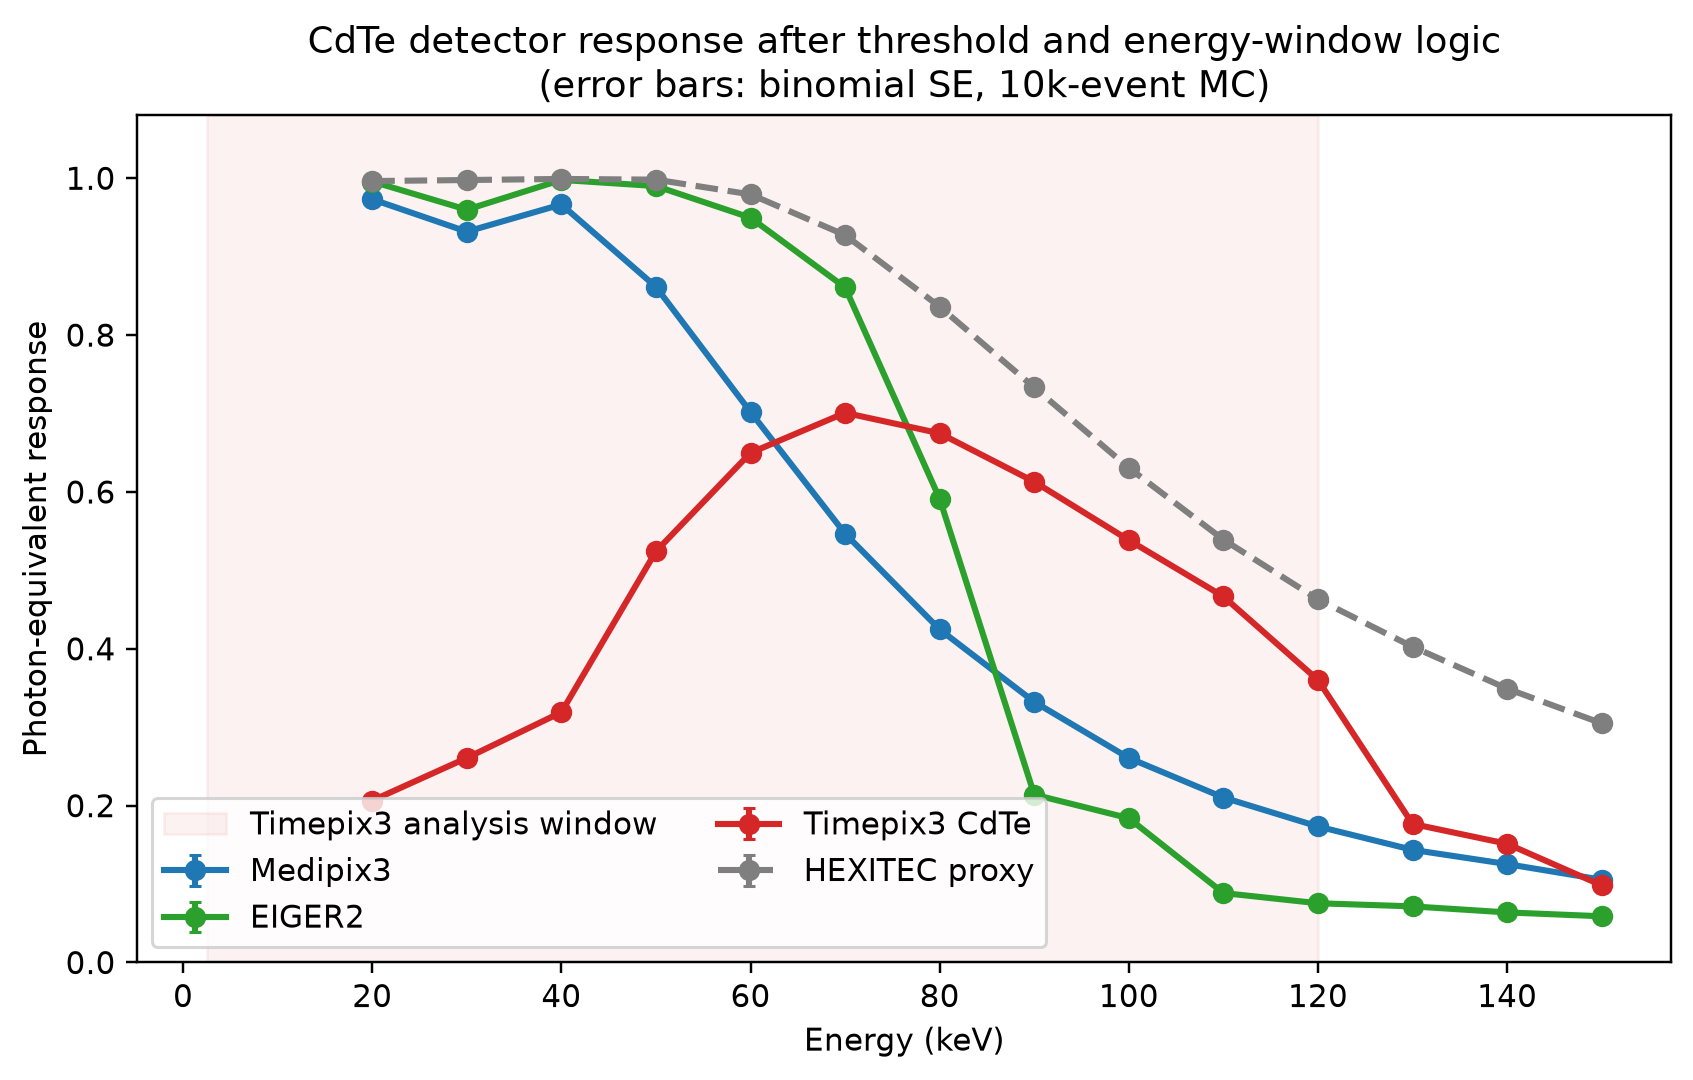

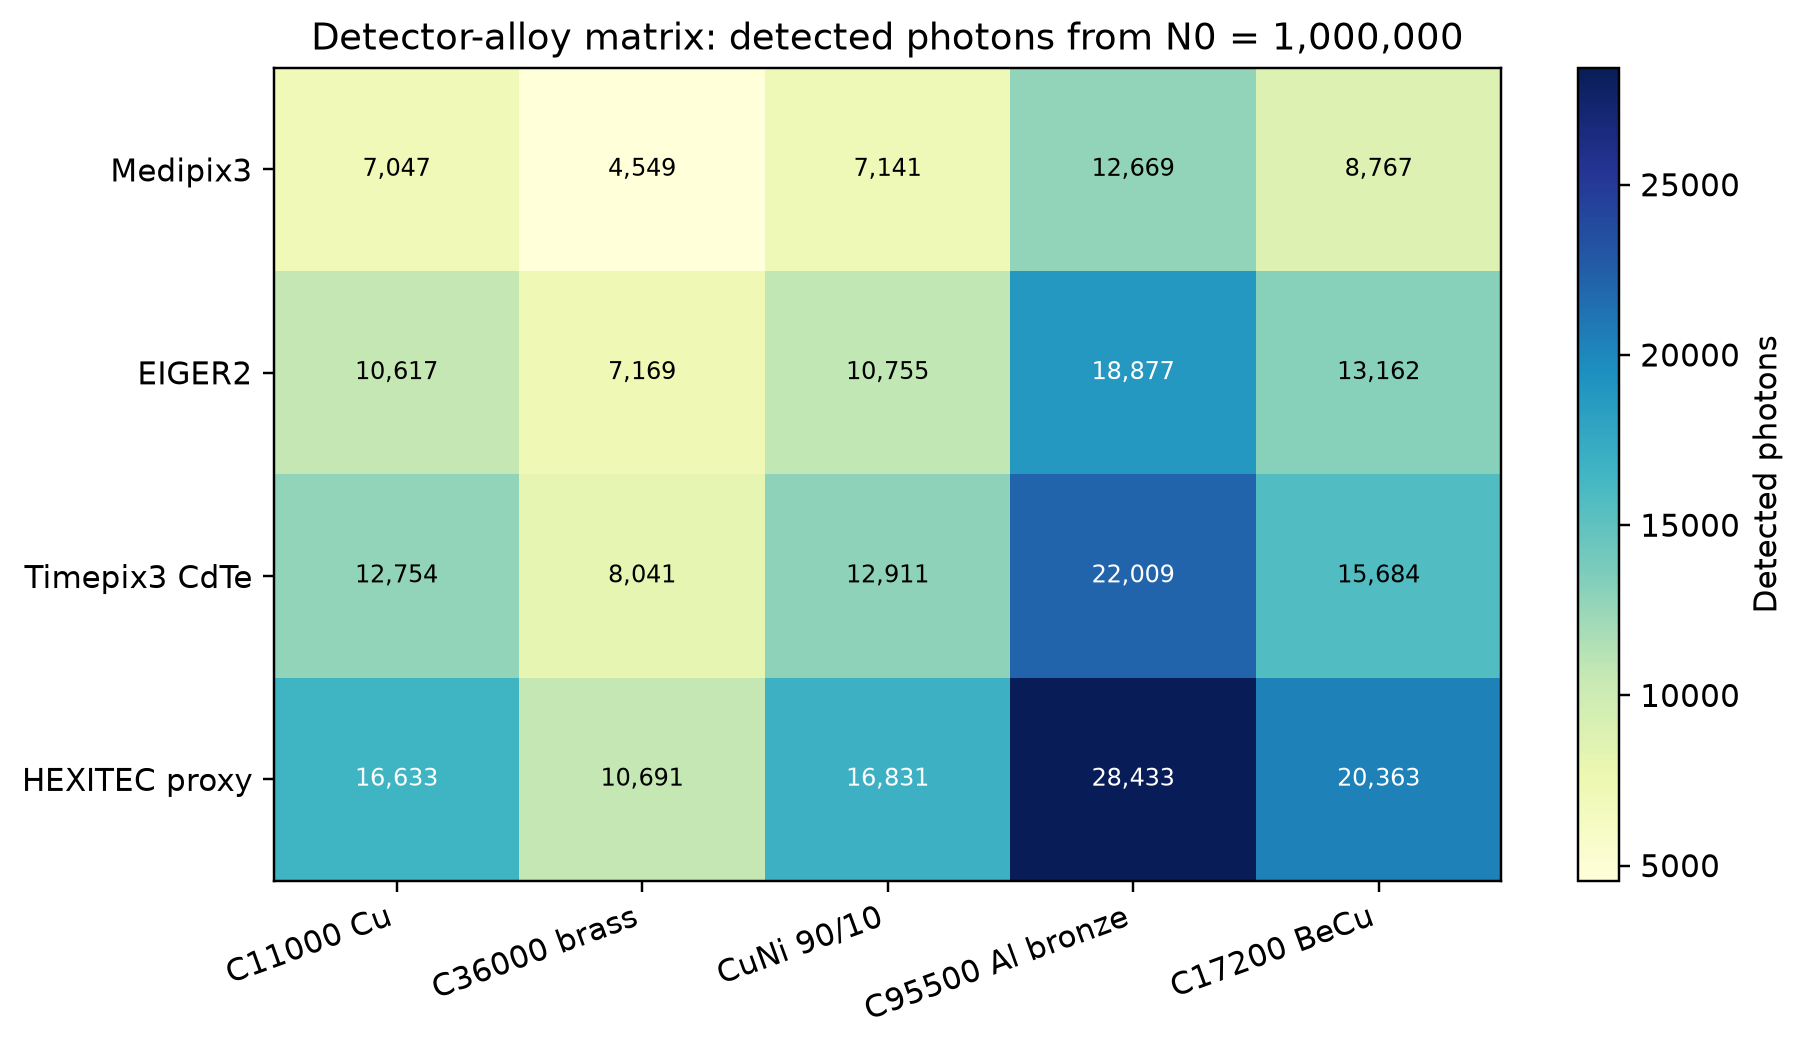

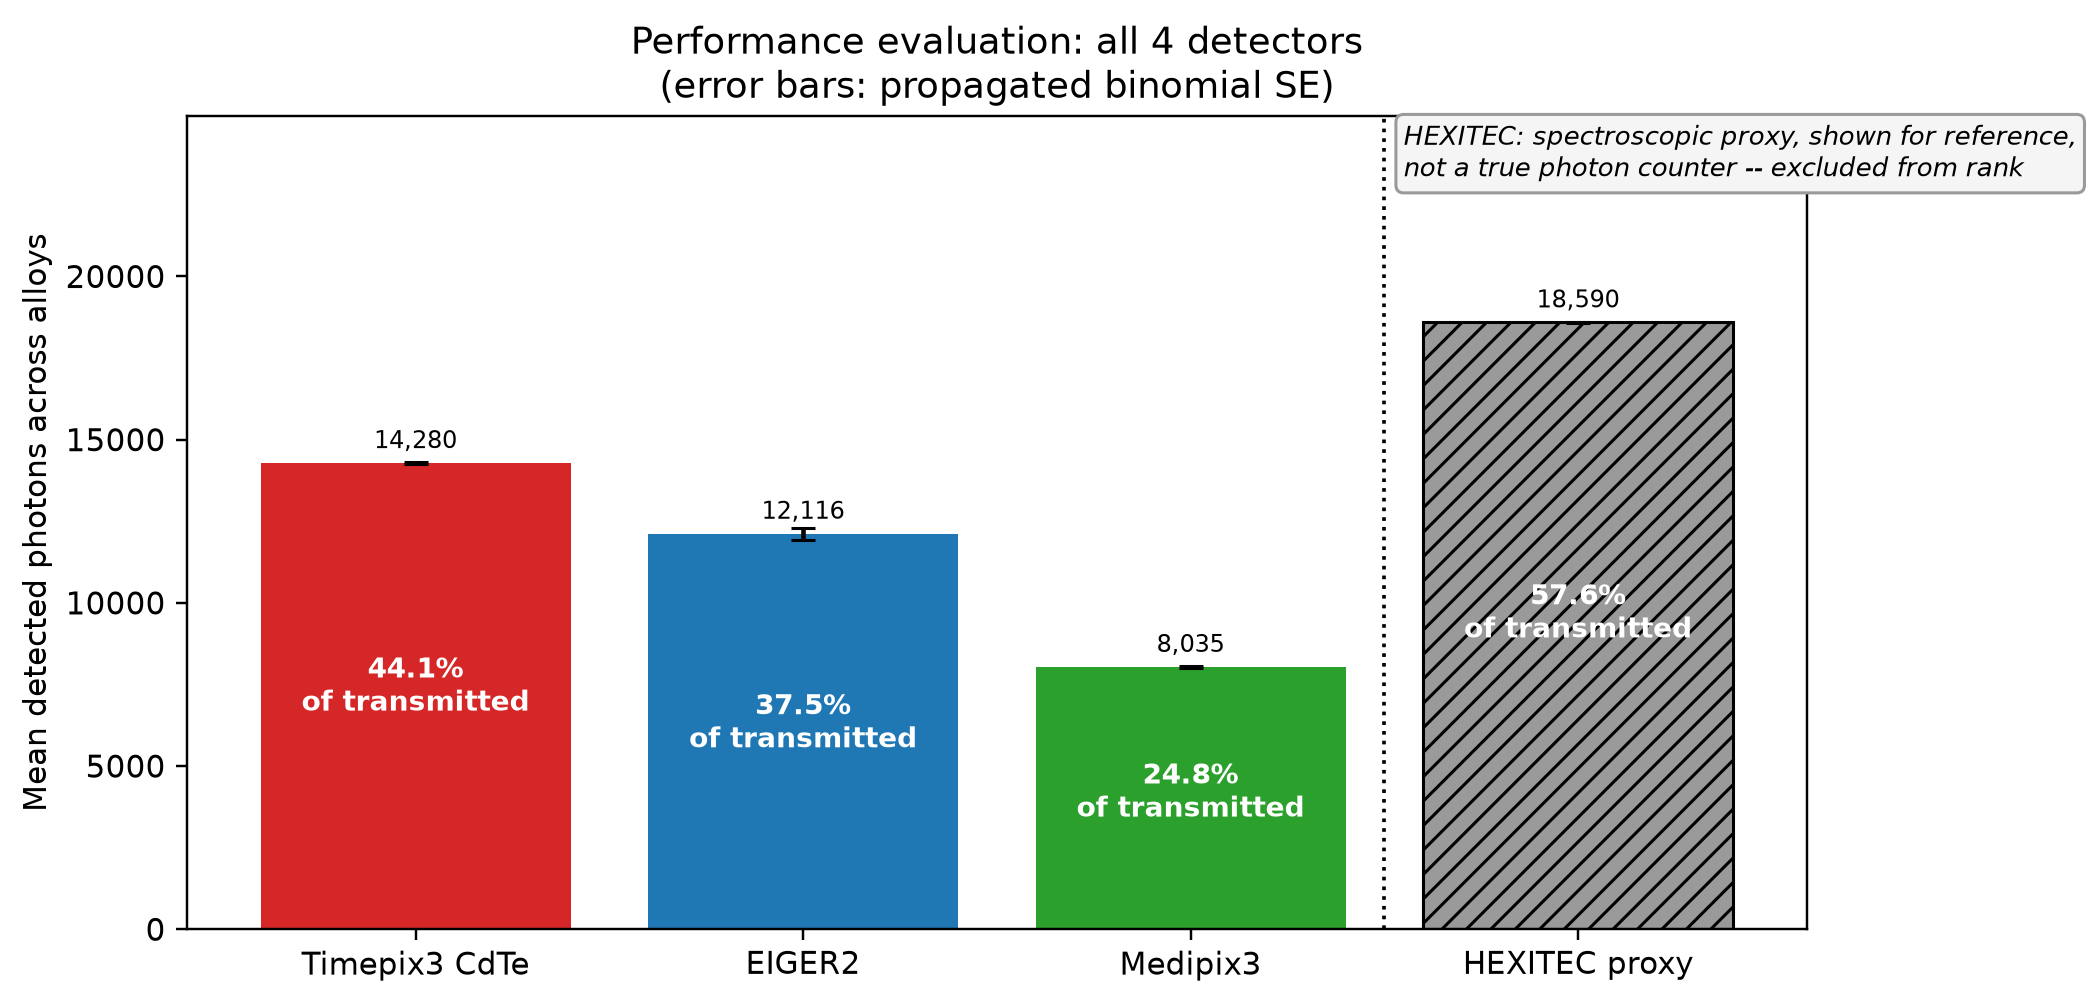

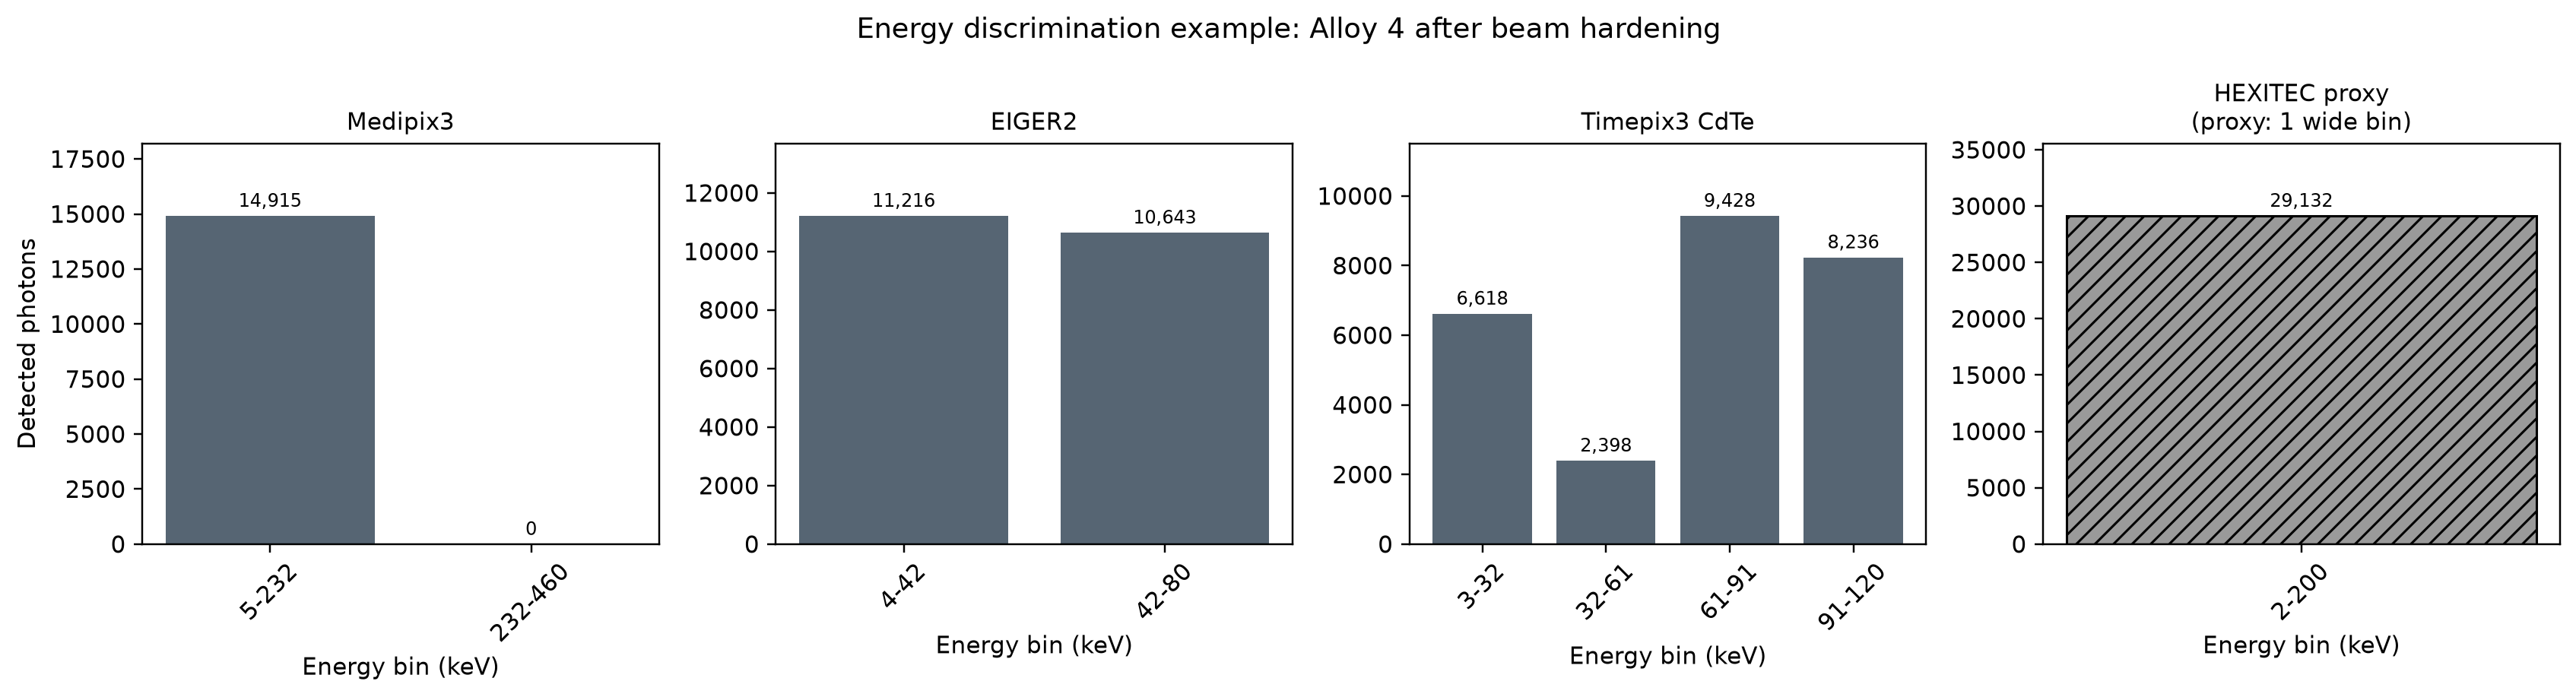

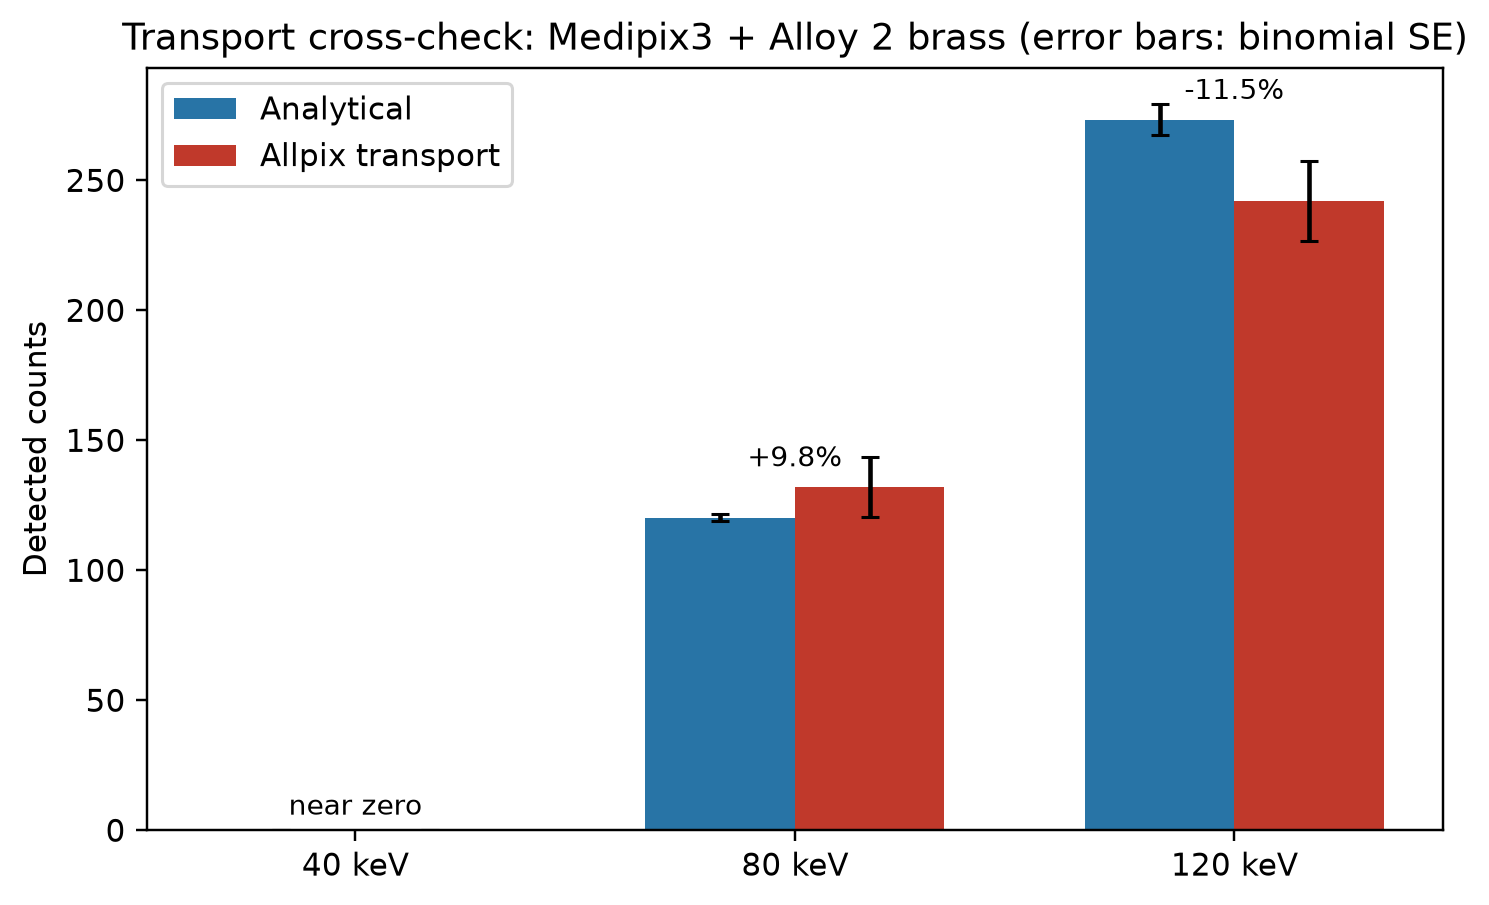

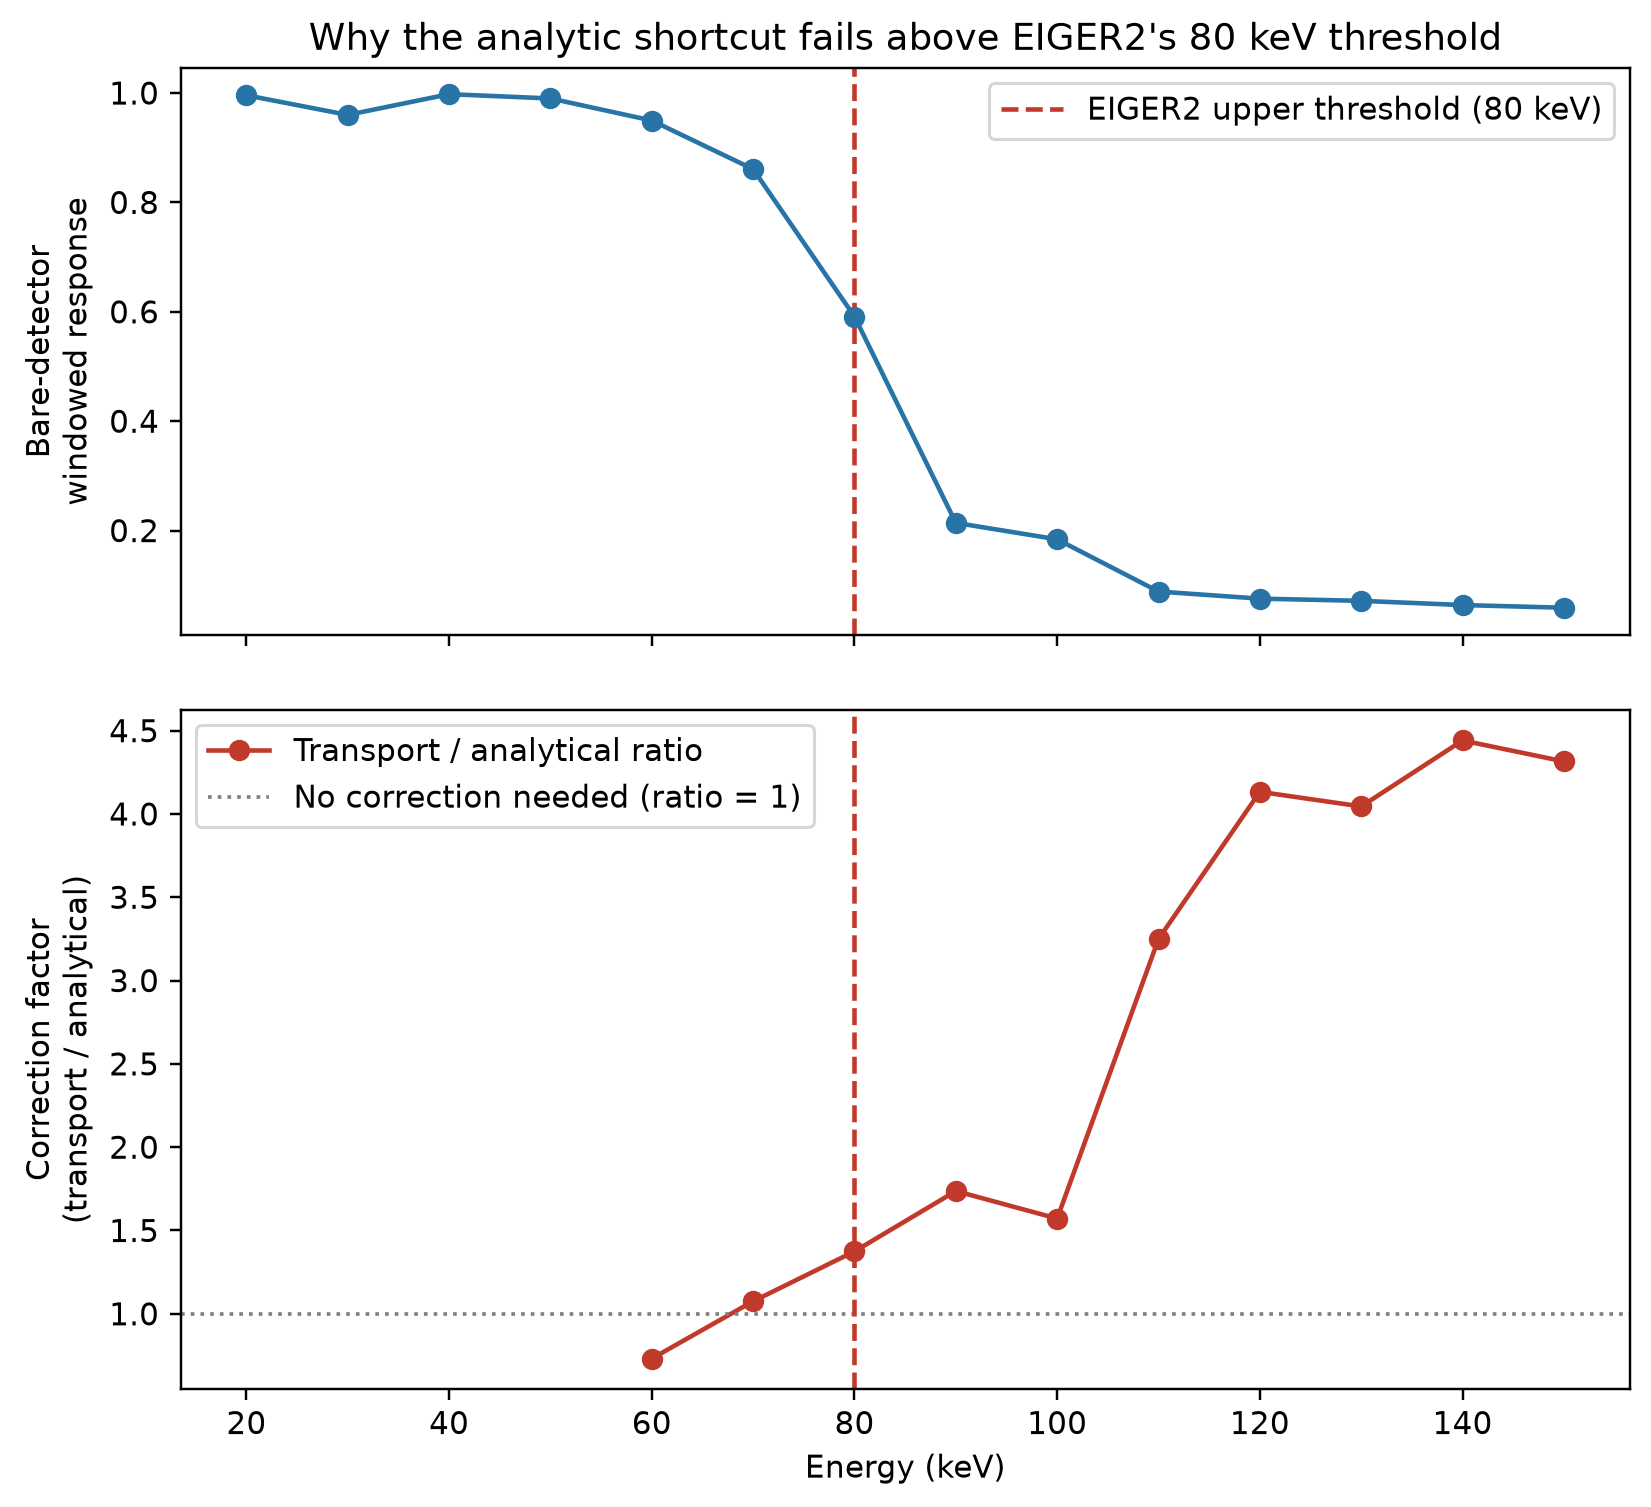

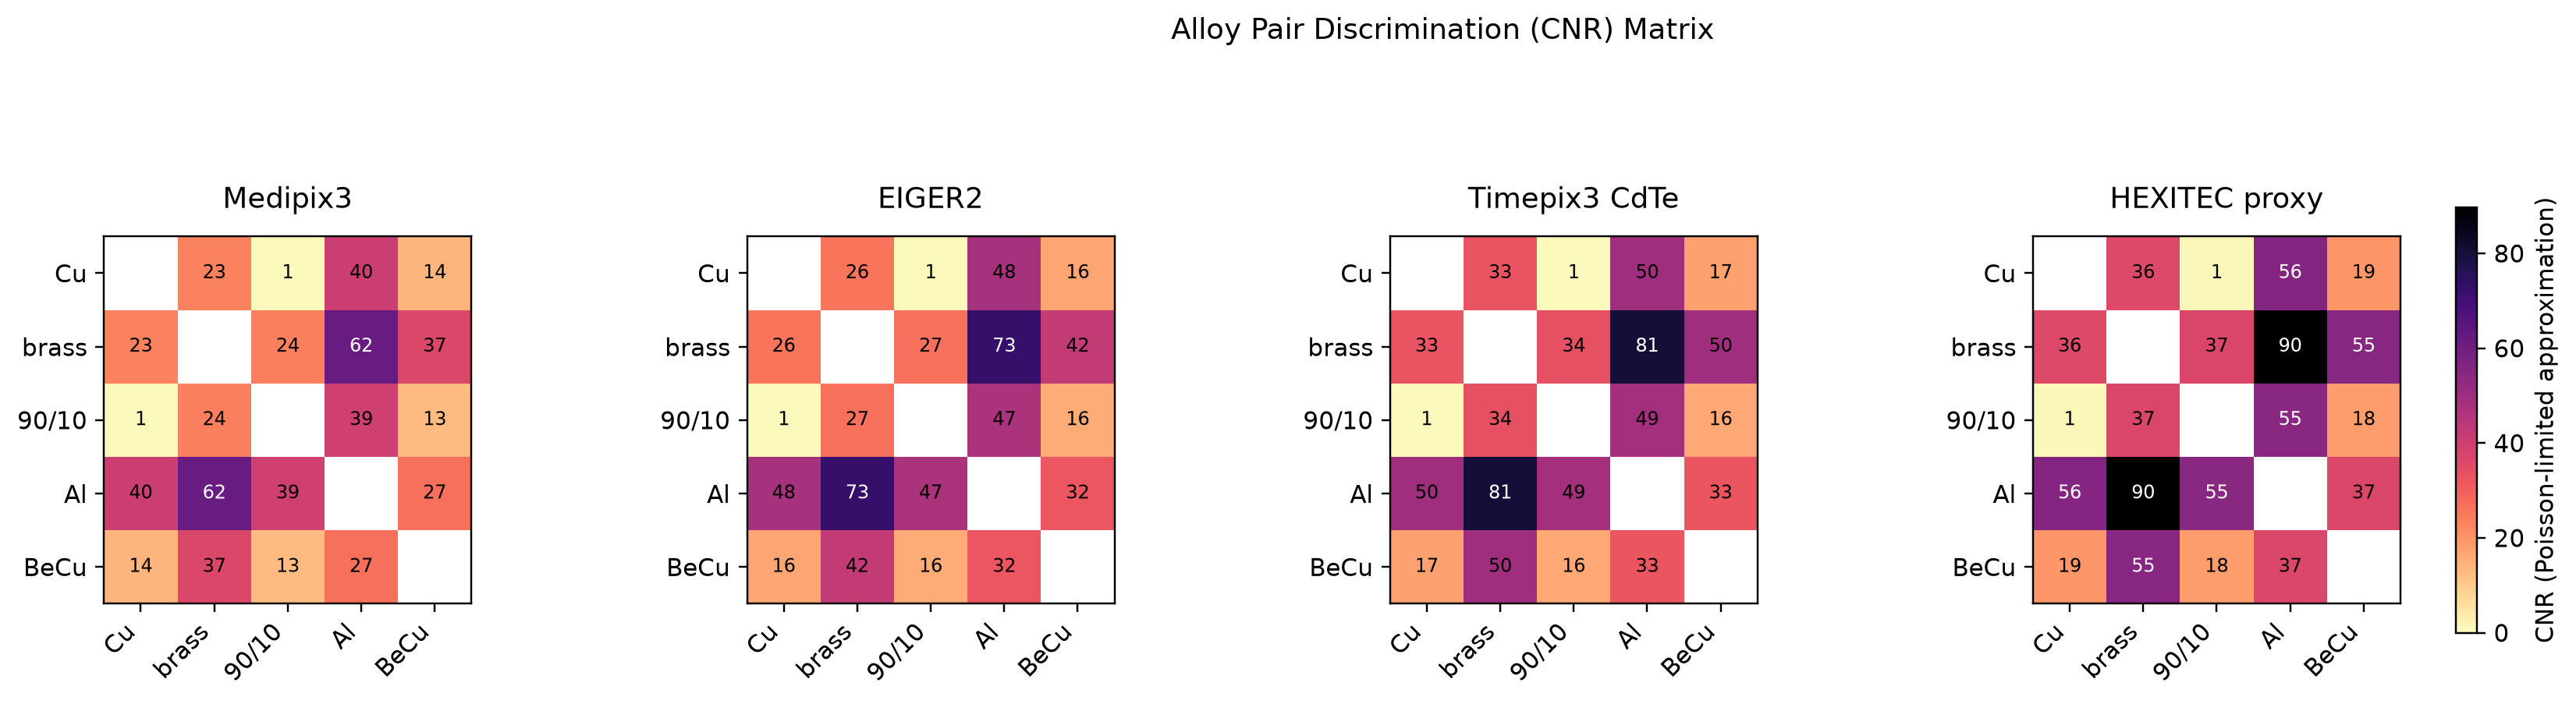

In [2]:
FIG_DIR = BASE / 'presentation_figures'
figure_files = [
    '01_xray_source_model.png',
    '02_alloy_transmission_heatmap.png',
    '03_cdte_detector_response.png',
    '04_detector_alloy_matrix_heatmap.png',
    '05_real_detector_performance.png',
    '06_energy_bin_discrimination_alloy4.png',
    '07_transport_cross_check.png',
    '08_eiger2_transport_correction.png',
    '09_alloy_discrimination_cnr.png',
]
for name in figure_files:
    display(Image(filename=str(FIG_DIR / name)))


## Validation Status

In [3]:
checks

,check,passed,detail
0,spectrum_weights_sum_to_1,True,1.00000011
1,spectrum_peak_and_mean_from_make_spectrum,True,"peak=60.0 keV, mean=60.5 keV"
2,bare_detector_responses_present,True,0 missing response rows out of 56
3,detector_energy_bin_logic_present,True,"126 detector-bin rows, expected 126"
4,transmitted_never_exceeds_incident,True,checked all per-energy bins
5,detected_never_exceeds_transmitted,True,checked 210 analytic-method per-energy bins (7...
6,beam_hardening_nonnegative,True,attenuating alloys should shift mean transmitt...
7,all_20_detector_alloy_combinations_present,True,20 combinations
8,hexitec_labelled_as_proxy,True,HEXITEC rows carry proxy_result=True
9,transport_validation_rows_present,True,"23 rows, expected 23 (3 detectors x 3 spot-che..."


## Source Spectrum

,weights_sum,mean_energy_keV,peak_energy_keV,energy_count
0,1.0,60.454914,60.0,14


,energy_keV,weight
0,20.0,0.032720
1,30.0,0.124761
2,40.0,0.155665
3,50.0,0.141723
4,60.0,0.205252
5,70.0,0.110289
6,80.0,0.062562
7,90.0,0.051067
8,100.0,0.040435
9,110.0,0.030876


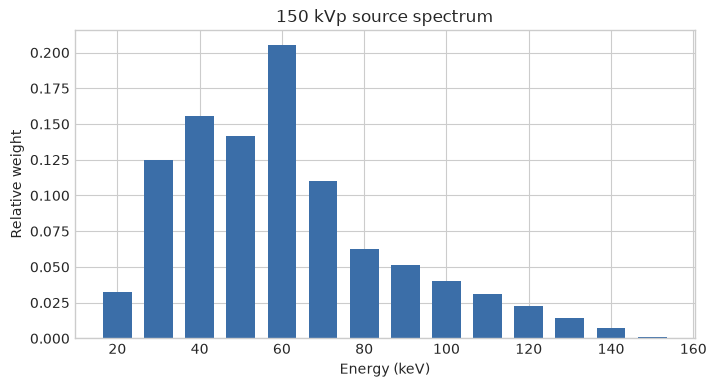

In [4]:
display(spectrum_summary)
display(spectrum)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(spectrum['energy_keV'], spectrum['weight'], width=7, color='#3b6ea8')
ax.set_title('150 kVp source spectrum')
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('Relative weight')
plt.show()

## Bare Detector Response

detector,eiger2,hexitec_proxy,medipix3,timepix3_cdte
energy_keV,,,,
20.0,0.9958,0.9964,0.9732,0.2064
30.0,0.9599,0.9977,0.9319,0.2608
40.0,0.9978,0.9991,0.9666,0.3191
50.0,0.9900,0.9982,0.8615,0.5242
60.0,0.9496,0.9794,0.7020,0.6498
70.0,0.8608,0.9275,0.5468,0.7009
80.0,0.5913,0.8362,0.4247,0.6748
90.0,0.2141,0.7332,0.3323,0.6130
100.0,0.1840,0.6307,0.2608,0.5385


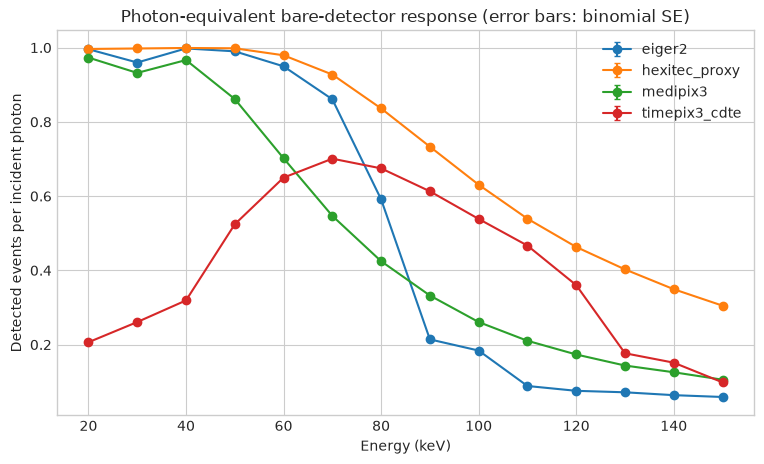

In [5]:
response_pivot = response.pivot(index='energy_keV', columns='detector', values='windowed_response')
response_se_pivot = response.pivot(index='energy_keV', columns='detector', values='windowed_response_se')
display(response_pivot.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for detector in response_pivot.columns:
    ax.errorbar(response_pivot.index, response_pivot[detector], yerr=response_se_pivot[detector], marker='o', capsize=2, label=detector)
ax.set_title('Photon-equivalent bare-detector response (error bars: binomial SE)')
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('Detected events per incident photon')
ax.legend()
plt.show()

## Detector Energy Bin Logic

In [6]:
display(detector_bins.head(20))

bin_summary = (
    bin_results.groupby(['detector', 'detector_energy_bin'], as_index=False)
    .agg(total_detected=('detected_in_detector_bin', 'sum'))
    .sort_values(['detector', 'detector_energy_bin'])
)
display(bin_summary.round(2))

,detector,detector_label,energy_keV,detector_energy_bin,bin_low_keV,bin_high_keV,bin_cluster_count,bin_response,proxy_result
0,medipix3,D1 Medipix3 CdTe,20.0,1,5.0,232.5,9734.0,0.9734,False
1,medipix3,D1 Medipix3 CdTe,20.0,2,232.5,460.0,0.0,0.0000,False
2,medipix3,D1 Medipix3 CdTe,30.0,1,5.0,232.5,10242.0,1.0242,False
3,medipix3,D1 Medipix3 CdTe,30.0,2,232.5,460.0,0.0,0.0000,False
4,medipix3,D1 Medipix3 CdTe,40.0,1,5.0,232.5,11250.0,1.1250,False
5,medipix3,D1 Medipix3 CdTe,40.0,2,232.5,460.0,0.0,0.0000,False
6,medipix3,D1 Medipix3 CdTe,50.0,1,5.0,232.5,10066.0,1.0066,False
7,medipix3,D1 Medipix3 CdTe,50.0,2,232.5,460.0,0.0,0.0000,False
8,medipix3,D1 Medipix3 CdTe,60.0,1,5.0,232.5,8274.0,0.8274,False
9,medipix3,D1 Medipix3 CdTe,60.0,2,232.5,460.0,0.0,0.0000,False


,detector,detector_energy_bin,total_detected
0,eiger2,1,39377.50
1,eiger2,2,30866.29
2,hexitec_proxy,1,95364.66
3,medipix3,1,47290.19
4,medipix3,2,0.00
5,timepix3_cdte,1,21853.10
6,timepix3_cdte,2,6540.14
7,timepix3_cdte,3,28699.43
8,timepix3_cdte,4,29624.51


## Alloy Transmission

alloy,alloy1,alloy2,alloy3,alloy4,alloy5
energy_keV,,,,,
20.0,2.806208e-66,3.029655e-68,8.231479e-66,6.745343e-50,3.902192e-60
30.0,6.932708e-22,1.066569e-22,1.012549e-21,1.368902e-16,6.612609e-20
40.0,3.718382e-10,1.438770e-10,4.423743e-10,8.319417e-08,2.817138e-09
50.0,8.551675e-06,4.938797e-06,9.380059e-06,1.524776e-04,2.526702e-05
60.0,8.132746e-04,5.761435e-04,8.589714e-04,4.597820e-03,1.567968e-03
70.0,8.264617e-03,6.591923e-03,8.549696e-03,2.598844e-02,1.282351e-02
80.0,3.310901e-02,2.830312e-02,3.385643e-02,7.352543e-02,4.511434e-02
90.0,7.392065e-02,3.308910e-02,7.505026e-02,1.340802e-01,9.343995e-02
100.0,1.289747e-01,7.021430e-02,1.303494e-01,2.035863e-01,1.547745e-01


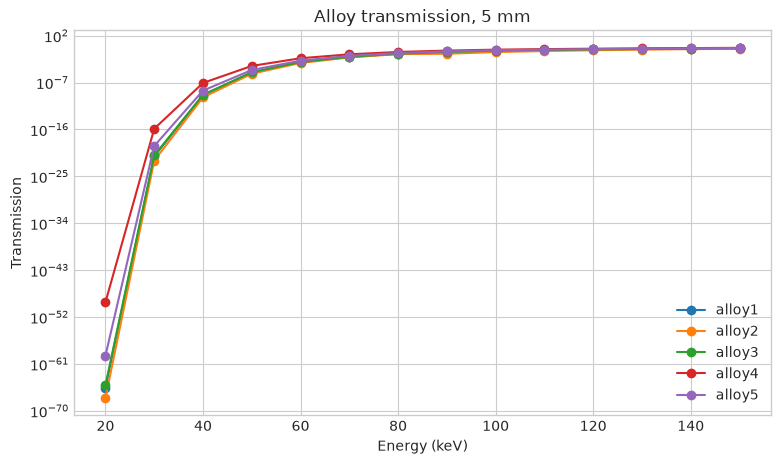

In [7]:
transmission_pivot = attenuation.pivot(index='energy_keV', columns='alloy', values='transmission')
display(transmission_pivot)

fig, ax = plt.subplots(figsize=(9, 5))
for alloy in transmission_pivot.columns:
    ax.plot(transmission_pivot.index, transmission_pivot[alloy], marker='o', label=alloy)
ax.set_yscale('log')
ax.set_title('Alloy transmission, 5 mm')
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('Transmission')
ax.legend()
plt.show()

## Combined Detector-Alloy Results

,detector,alloy,transmitted_total,detected_total,detected_total_se,transmission_fraction,detected_fraction_of_incident,detected_fraction_of_transmitted,mean_transmitted_energy_keV,beam_hardening_shift_keV,proxy_result
13,hexitec_proxy,alloy4,46976.1300,28432.7180,80.5651,0.0470,0.0284,0.6053,104.7991,44.3442,True
18,timepix3_cdte,alloy4,46976.1300,22009.3562,81.6782,0.0470,0.0220,0.4685,104.7991,44.3442,False
14,hexitec_proxy,alloy5,35141.8478,20362.5493,62.9630,0.0351,0.0204,0.5794,107.7706,47.3157,True
8,eiger2,alloy4,46976.1300,18877.3750,657.7549,0.0470,0.0189,0.4019,104.7991,44.3442,False
12,hexitec_proxy,alloy3,29642.9566,16830.8689,54.1091,0.0296,0.0168,0.5678,109.1212,48.6663,True
10,hexitec_proxy,alloy1,29352.6390,16633.0591,53.6741,0.0294,0.0166,0.5667,109.2518,48.7969,True
19,timepix3_cdte,alloy5,35141.8478,15683.8104,62.4577,0.0351,0.0157,0.4463,107.7706,47.3157,False
9,eiger2,alloy5,35141.8478,13161.5483,388.0458,0.0351,0.0132,0.3745,107.7706,47.3157,False
17,timepix3_cdte,alloy3,29642.9566,12911.1557,53.1789,0.0296,0.0129,0.4356,109.1212,48.6663,False
15,timepix3_cdte,alloy1,29352.6390,12753.5781,52.7043,0.0294,0.0128,0.4345,109.2518,48.7969,False


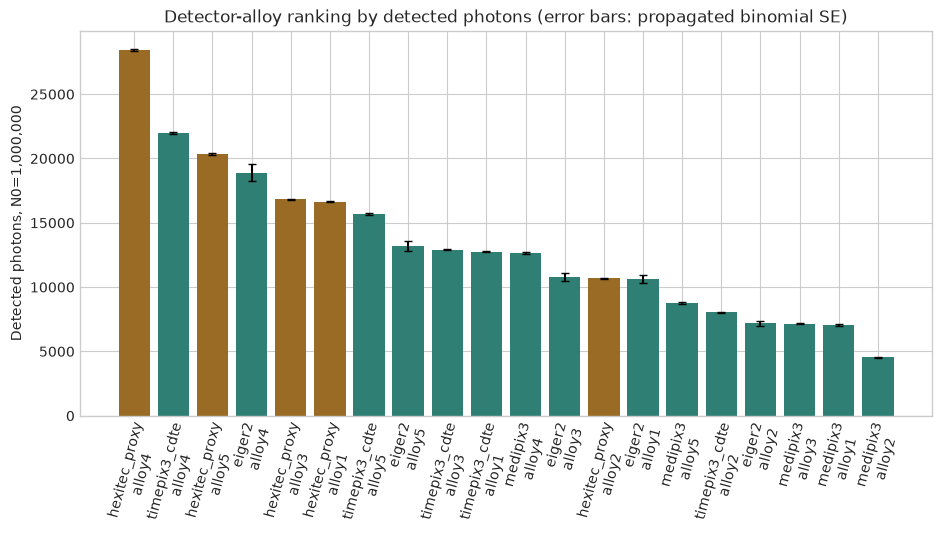

In [8]:
cols = [
    'detector', 'alloy', 'transmitted_total', 'detected_total', 'detected_total_se',
    'transmission_fraction', 'detected_fraction_of_incident',
    'detected_fraction_of_transmitted', 'mean_transmitted_energy_keV',
    'beam_hardening_shift_keV', 'proxy_result'
]
display(combined[cols].sort_values('detected_total', ascending=False).round(4))

fig, ax = plt.subplots(figsize=(11, 5))
ranked = combined.sort_values('detected_total', ascending=False).copy()
ranked['label'] = ranked['detector'] + '\n' + ranked['alloy']
colors = ranked['proxy_result'].map({True: '#9a6b24', False: '#2f7f74'})
ax.bar(ranked['label'], ranked['detected_total'], yerr=ranked['detected_total_se'], capsize=3, color=colors)
ax.set_title('Detector-alloy ranking by detected photons (error bars: propagated binomial SE)')
ax.set_ylabel('Detected photons, N0=1,000,000')
ax.tick_params(axis='x', labelrotation=75)
plt.show()

## Beam Hardening

detector,eiger2,hexitec_proxy,medipix3,timepix3_cdte
alloy,,,,
alloy1,48.80,48.80,48.80,48.80
alloy2,50.01,50.01,50.01,50.01
alloy3,48.67,48.67,48.67,48.67
alloy4,44.34,44.34,44.34,44.34
alloy5,47.32,47.32,47.32,47.32


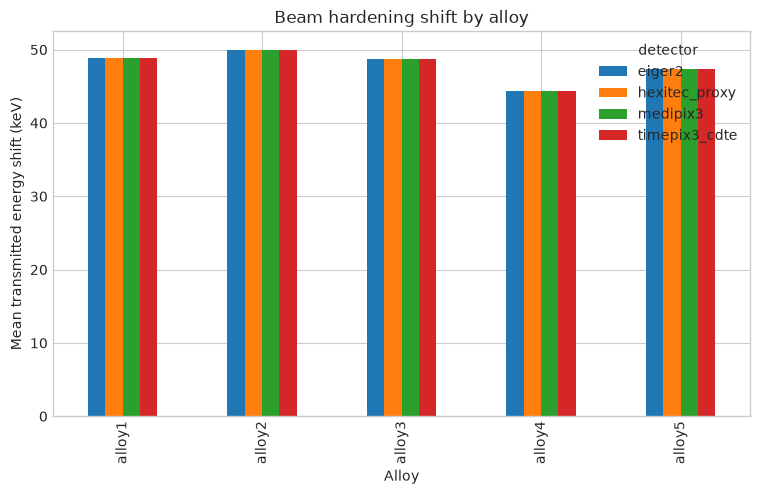

In [9]:
beam = combined.pivot(index='alloy', columns='detector', values='beam_hardening_shift_keV')
display(beam.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
beam.plot(kind='bar', ax=ax)
ax.set_title('Beam hardening shift by alloy')
ax.set_xlabel('Alloy')
ax.set_ylabel('Mean transmitted energy shift (keV)')
plt.show()

## Transport Cross-Check

,detector,alloy,energy_keV,validation_events,analytical_transmission,analytical_detected_fraction,analytical_detected_fraction_se,analytical_detected_counts,analytical_detected_counts_se,transport_detected_counts,transport_detected_counts_se,transport_detected_fraction,transport_detected_fraction_se,relative_difference_pct,root_file,status
0,medipix3,alloy2,40.0,10000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,NaN,/home/victor-pc/itek/senstech-simulation/data/...,ok
1,medipix3,alloy2,80.0,10000,0.0283,0.0120,0.0001,120.2003,1.3990,132.0,11.4130,0.0132,0.0011,9.8167,/home/victor-pc/itek/senstech-simulation/data/...,ok
2,medipix3,alloy2,120.0,10000,0.1576,0.0273,0.0006,273.2987,5.9668,242.0,15.3670,0.0242,0.0015,-11.4522,/home/victor-pc/itek/senstech-simulation/data/...,ok
3,eiger2,alloy2,20.0,10000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,NaN,/home/victor-pc/itek/senstech-simulation/data/...,ok
4,eiger2,alloy2,30.0,10000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,NaN,/home/victor-pc/itek/senstech-simulation/data/...,ok
5,eiger2,alloy2,40.0,10000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,NaN,/home/victor-pc/itek/senstech-simulation/data/...,ok
6,eiger2,alloy2,50.0,10000,0.0000,0.0000,0.0000,0.0489,0.0000,0.0,0.0000,0.0000,0.0000,NaN,/home/victor-pc/itek/senstech-simulation/data/...,ok
7,eiger2,alloy2,60.0,10000,0.0006,0.0005,0.0000,5.4713,0.0126,4.0,1.9996,0.0004,0.0002,-26.8917,/home/victor-pc/itek/senstech-simulation/data/...,ok
8,eiger2,alloy2,70.0,10000,0.0066,0.0057,0.0000,56.7400,0.2282,61.0,7.7864,0.0061,0.0008,7.5079,/home/victor-pc/itek/senstech-simulation/data/...,ok
9,eiger2,alloy2,80.0,10000,0.0283,0.0167,0.0001,167.3468,1.3914,230.0,14.9903,0.0230,0.0015,37.4391,/home/victor-pc/itek/senstech-simulation/data/...,ok


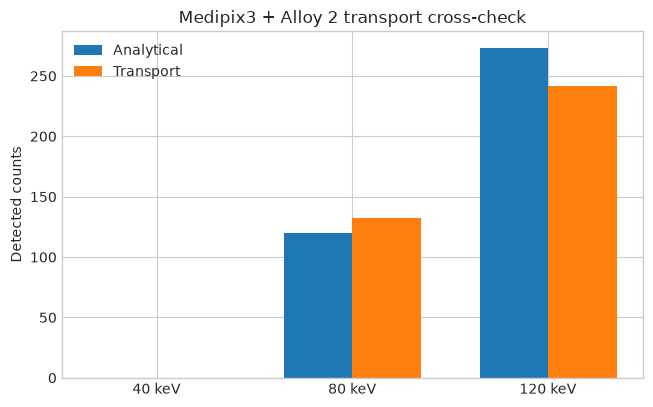

In [10]:
display(transport.round(4))

medipix3_transport = transport[transport['detector'] == 'medipix3'].sort_values('energy_keV').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = range(len(medipix3_transport))
width = 0.35
ax.bar([i - width / 2 for i in x], medipix3_transport['analytical_detected_counts'], width, label='Analytical')
ax.bar([i + width / 2 for i in x], medipix3_transport['transport_detected_counts'], width, label='Transport')
ax.set_xticks(list(x), [f"{e:.0f} keV" for e in medipix3_transport['energy_keV']])
ax.set_title('Medipix3 + Alloy 2 transport cross-check')
ax.set_ylabel('Detected counts')
ax.legend()
plt.show()

## EIGER2 Transport Correction

EIGER2 is the only detector where the analytic shortcut breaks down badly (see `relative_difference_pct` above). The two panels below share an energy axis: the top panel is EIGER2's bare-detector response, showing its 80 keV threshold cliff; the bottom panel is the resulting correction factor (transport / analytical), which stays near 1 until that same threshold and rises sharply after it. This is why EIGER2/alloy2 uses the directly measured transport fraction, and its other four alloys use an alloy2-calibrated correction factor.

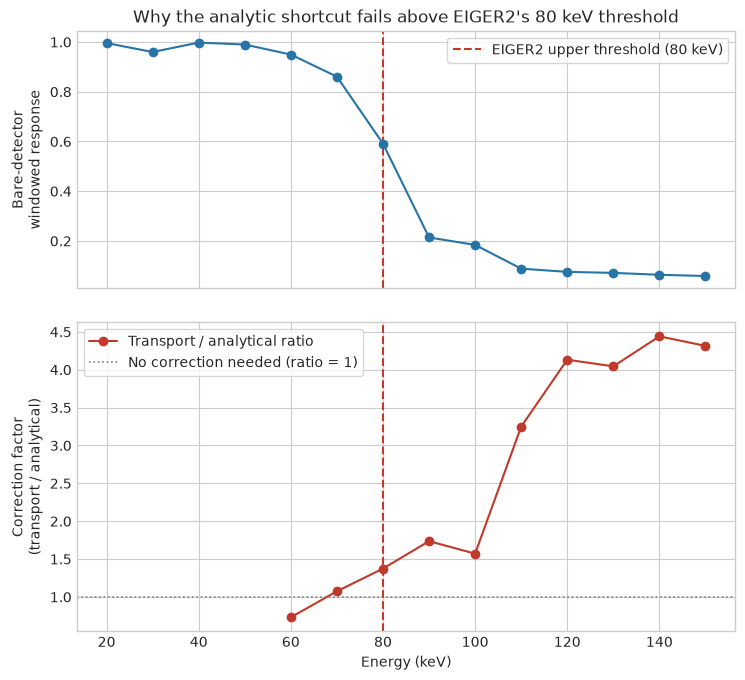

In [11]:
eiger2_response = response[response['detector'] == 'eiger2'].sort_values('energy_keV')
eiger2_transport = transport[transport['detector'] == 'eiger2'].sort_values('energy_keV').copy()
eiger2_transport['correction_factor'] = np.where(
    eiger2_transport['analytical_detected_counts'] >= 1.0,
    eiger2_transport['transport_detected_fraction'] / eiger2_transport['analytical_detected_fraction'],
    np.nan,
)
valid = eiger2_transport.dropna(subset=['correction_factor'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 7.8), sharex=True, gridspec_kw={'height_ratios': [1, 1.2], 'hspace': 0.12})
ax1.errorbar(eiger2_response['energy_keV'], eiger2_response['windowed_response'], yerr=eiger2_response['windowed_response_se'], marker='o', capsize=2, color='#2874a6')
ax1.axvline(80, color='#c0392b', ls='--', lw=1.5, label='EIGER2 upper threshold (80 keV)')
ax1.set_ylabel('Bare-detector\nwindowed response')
ax1.set_title("Why the analytic shortcut fails above EIGER2's 80 keV threshold")
ax1.legend(frameon=True, loc='upper right')

ax2.plot(valid['energy_keV'], valid['correction_factor'], marker='o', color='#c0392b', label='Transport / analytical ratio')
ax2.axhline(1.0, color='gray', ls=':', lw=1.2, label='No correction needed (ratio = 1)')
ax2.axvline(80, color='#c0392b', ls='--', lw=1.5)
ax2.set_ylabel('Correction factor\n(transport / analytical)')
ax2.set_xlabel('Energy (keV)')
ax2.legend(frameon=True, loc='upper left')
plt.show()

## Alloy Discrimination (CNR)

Detected-count ranking (above) answers "which combo detects the most photons." This answers a different, more directly practical question: can a given detector actually tell two alloys apart? `CNR = |N_a - N_b| / sqrt(N_a + N_b)` using each alloy's detected_total as signal and combined Poisson shot noise as reference -- a Poisson-limited approximation (no electronic noise), so an upper bound on achievable discrimination.

In [12]:
display(discrimination.sort_values(['detector', 'cnr']).round(2))

hardest = discrimination.loc[discrimination['cnr'].idxmin()]
easiest = discrimination.loc[discrimination['cnr'].idxmax()]
print(f"Hardest pair to distinguish: {hardest['alloy_a']} vs {hardest['alloy_b']} (CNR={hardest['cnr']:.2f}, {hardest['detector']})")
print(f"Easiest pair to distinguish: {easiest['alloy_a']} vs {easiest['alloy_b']} (CNR={easiest['cnr']:.2f}, {easiest['detector']})")

,detector,detector_label,alloy_a,alloy_b,detected_total_a,detected_total_b,cnr,proxy_result
11,eiger2,D2 EIGER2 CdTe,alloy1,alloy3,10617.39,10754.86,0.94,False
18,eiger2,D2 EIGER2 CdTe,alloy3,alloy5,10754.86,13161.55,15.56,False
13,eiger2,D2 EIGER2 CdTe,alloy1,alloy5,10617.39,13161.55,16.50,False
10,eiger2,D2 EIGER2 CdTe,alloy1,alloy2,10617.39,7169.40,25.85,False
14,eiger2,D2 EIGER2 CdTe,alloy2,alloy3,7169.40,10754.86,26.78,False
19,eiger2,D2 EIGER2 CdTe,alloy4,alloy5,18877.37,13161.55,31.93,False
16,eiger2,D2 EIGER2 CdTe,alloy2,alloy5,7169.40,13161.55,42.02,False
17,eiger2,D2 EIGER2 CdTe,alloy3,alloy4,10754.86,18877.37,47.19,False
12,eiger2,D2 EIGER2 CdTe,alloy1,alloy4,10617.39,18877.37,48.10,False
15,eiger2,D2 EIGER2 CdTe,alloy2,alloy4,7169.40,18877.37,72.54,False


Hardest pair to distinguish: alloy1 vs alloy3 (CNR=0.79, medipix3)
Easiest pair to distinguish: alloy2 vs alloy4 (CNR=89.70, hexitec_proxy)
